# 🐦 Twitter Sentiment Analysis with RoBERTa

Uses `cardiffnlp/twitter-roberta-base-sentiment` — a RoBERTa model fine-tuned on **58M tweets**.

**Dataset:** Sentiment140 — 1.6 million tweets labeled Positive / Negative

**Output:** Predicted sentiment → **Negative / Neutral / Positive** with confidence scores

---

## 📦 Step 1: Install & Import Dependencies

In [ ]:
!pip install transformers torch scipy kaggle -q

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
from scipy.special import softmax
import torch
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import warnings
warnings.filterwarnings('ignore')

plt.style.use('ggplot')
print('✅ Libraries imported!')
print(f'GPU available: {torch.cuda.is_available()}')

✅ Libraries imported!
GPU available: False


## 📥 Step 2: Download & Load Dataset

> Upload your `kaggle.json` file to Colab before running this cell.
> Get it from: kaggle.com → Profile → Settings → API → Create New Token

In [ ]:
# Setup Kaggle credentials
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

# Download Sentiment140
!kaggle datasets download -d kazanova/sentiment140

# Extract
from zipfile import ZipFile
with ZipFile('sentiment140.zip', 'r') as z:
    z.extractall()

print('✅ Dataset downloaded and extracted!')
!ls *.csv

Dataset URL: https://www.kaggle.com/datasets/kazanova/sentiment140
License(s): other
100% 80.9M/80.9M [00:00<00:00, 159MB/s]

✅ Dataset downloaded and extracted!
training.1600000.processed.noemoticon.csv


In [ ]:
# Sentiment140 columns (no header in the file)
COLUMNS = ['target', 'id', 'date', 'flag', 'user', 'text']

df = pd.read_csv('training.1600000.processed.noemoticon.csv',
                 encoding='latin-1', header=None, names=COLUMNS)

print(f'Full dataset shape: {df.shape}')
df.head()

Full dataset shape: (1600000, 6)


,target,id,date,flag,user,text
0,0,1467810369,Mon Apr 06 22:19:45 PDT 2009,NO_QUERY,_TheSpecialOne_,"@switchfoot http://twitpic.com/2y1zl - Awww, t..."
1,0,1467810672,Mon Apr 06 22:19:49 PDT 2009,NO_QUERY,scotthamilton,is upset that he can't update his Facebook by ...
2,0,1467810917,Mon Apr 06 22:19:53 PDT 2009,NO_QUERY,mattycus,@Kenichan I dived many times for the ball. Man...
3,0,1467811184,Mon Apr 06 22:19:57 PDT 2009,NO_QUERY,ElleCTF,my whole body feels itchy and like its on fire
4,0,1467811193,Mon Apr 06 22:19:57 PDT 2009,NO_QUERY,Karoli,"@nationwideclass no, it's not behaving at all...."


In [ ]:
# Target: 0 = Negative, 4 = Positive → remap to 0/1
df['target'] = df['target'].replace(4, 1)

# Sample balanced subset: 500 each class (1000 total)
# Increase this for better evaluation; keep low for CPU speed
neg_sample = df[df['target'] == 0].sample(500, random_state=42)
pos_sample = df[df['target'] == 1].sample(500, random_state=42)
df_sample = pd.concat([neg_sample, pos_sample]).sample(frac=1, random_state=42).reset_index(drop=True)

df_sample['true_sentiment'] = df_sample['target'].map({0: 'Negative', 1: 'Positive'})

print(f'Working subset: {df_sample.shape}')
print(df_sample['true_sentiment'].value_counts())
df_sample[['target', 'true_sentiment', 'text']].head()

Working subset: (1000, 7)
true_sentiment
Positive    500
Negative    500
Name: count, dtype: int64


,target,true_sentiment,text
0,1,Positive,@indiemoviemaker thanks 4 including me in your...
1,1,Positive,No santigold for me tonight. work til 10 and I...
2,1,Positive,@JonathanRKnight for realz! Safe travels- hope...
3,1,Positive,"@thomaskattus you asked about my SF schedule, ..."
4,0,Negative,My throat kinda hurts


## 🔍 Step 3: Exploratory Data Analysis

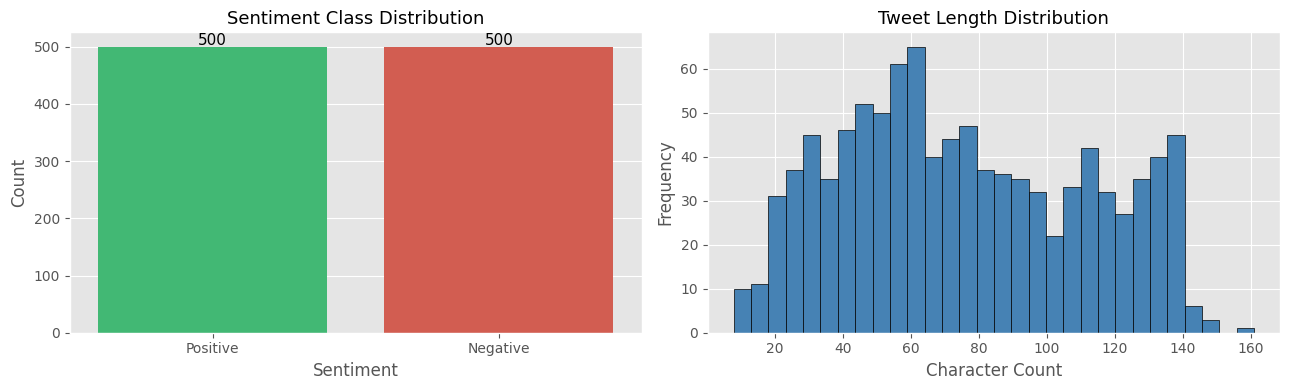

Average tweet length: 75.8 characters


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Class distribution
ax = sns.countplot(data=df_sample, x='true_sentiment',
                   palette={'Negative': '#e74c3c', 'Positive': '#2ecc71'}, ax=axes[0])
axes[0].set_title('Sentiment Class Distribution', fontsize=13)
axes[0].set_xlabel('Sentiment')
axes[0].set_ylabel('Count')
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}',
                (p.get_x() + p.get_width()/2, p.get_height() + 3),
                ha='center', fontsize=11)

# Tweet length distribution
df_sample['tweet_length'] = df_sample['text'].astype(str).apply(len)
axes[1].hist(df_sample['tweet_length'], bins=30, color='steelblue', edgecolor='black')
axes[1].set_title('Tweet Length Distribution', fontsize=13)
axes[1].set_xlabel('Character Count')
axes[1].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

print(f'Average tweet length: {df_sample["tweet_length"].mean():.1f} characters')

## 🧹 Step 4: Tweet Preprocessing

Clean tweets before passing to RoBERTa — remove URLs, mentions, and extra spaces.

> Note: RoBERTa handles raw text well, so we do **minimal** cleaning (no stemming/stopwords).

In [ ]:
def preprocess_tweet(text):
    """Minimal cleaning for RoBERTa:
       - Replace @mentions with @user (model was trained this way)
       - Replace URLs with http
       - Strip extra whitespace
    """
    text = str(text)
    text = re.sub(r'@\w+', '@user', text)          # mentions → @user
    text = re.sub(r'http\S+|www\S+', 'http', text) # URLs → http
    text = re.sub(r'\s+', ' ', text).strip()        # extra spaces
    return text

df_sample['clean_text'] = df_sample['text'].apply(preprocess_tweet)

print('Original tweet:')
print(df_sample['text'].iloc[0])
print('\nAfter preprocessing:')
print(df_sample['clean_text'].iloc[0])

Original tweet:
@indiemoviemaker thanks 4 including me in your shoutout 

After preprocessing:
@user thanks 4 including me in your shoutout


## 🤖 Step 5: Load RoBERTa Model

> 💡 **Tip:** Go to Runtime → Change runtime type → T4 GPU for 10x faster inference!

In [ ]:
MODEL_NAME = 'cardiffnlp/twitter-roberta-base-sentiment'

print(f'Loading: {MODEL_NAME} ...')
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
model     = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model  = model.to(device)
model.eval()

# This model's label mapping
LABELS = {0: 'Negative', 1: 'Neutral', 2: 'Positive'}

print(f'✅ RoBERTa loaded on: {device}')

Loading: cardiffnlp/twitter-roberta-base-sentiment ...


config.json:   0%|          | 0.00/747 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/150 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/499M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

✅ RoBERTa loaded on: cpu


model.safetensors:   0%|          | 0.00/499M [00:00<?, ?B/s]

## 🔮 Step 6: Run Sentiment Inference

In [ ]:
def predict_roberta(text):
    """Returns predicted sentiment label + neg/neu/pos probabilities."""
    try:
        encoded = tokenizer(
            str(text),
            return_tensors='pt',
            truncation=True,
            max_length=512
        ).to(device)

        with torch.no_grad():
            output = model(**encoded)

        scores = softmax(output.logits[0].cpu().numpy())
        pred   = int(np.argmax(scores))

        return {
            'predicted_sentiment': LABELS[pred],
            'neg_score': round(float(scores[0]), 4),
            'neu_score': round(float(scores[1]), 4),
            'pos_score': round(float(scores[2]), 4)
        }
    except Exception:
        return {'predicted_sentiment': None,
                'neg_score': None, 'neu_score': None, 'pos_score': None}


print(f'Running RoBERTa on {len(df_sample)} tweets...')
print('(~5–10 min on CPU | ~1 min on GPU)')

results    = df_sample['clean_text'].apply(predict_roberta)
results_df = pd.DataFrame(results.tolist())
df_sample  = pd.concat([df_sample.reset_index(drop=True), results_df], axis=1)

print('✅ Inference complete!')
df_sample[['text', 'true_sentiment', 'predicted_sentiment',
           'neg_score', 'neu_score', 'pos_score']].head(10)

Running RoBERTa on 1000 tweets...
(~5–10 min on CPU | ~1 min on GPU)
✅ Inference complete!


,text,true_sentiment,predicted_sentiment,neg_score,neu_score,pos_score
0,@indiemoviemaker thanks 4 including me in your...,Positive,Positive,0.0016,0.0592,0.9392
1,No santigold for me tonight. work til 10 and I...,Positive,Neutral,0.0899,0.6769,0.2333
2,@JonathanRKnight for realz! Safe travels- hope...,Positive,Positive,0.0010,0.0101,0.9889
3,"@thomaskattus you asked about my SF schedule, ...",Positive,Neutral,0.1175,0.8202,0.0624
4,My throat kinda hurts,Negative,Negative,0.9373,0.0568,0.0059
5,"@Astro_127 Fingers crossed, and all the best t...",Positive,Positive,0.0053,0.0743,0.9205
6,kenny chesney concert was amazing!! i LOVE sug...,Positive,Positive,0.0025,0.0053,0.9922
7,@eve76 it would be fine if max and erma gave a...,Positive,Positive,0.0618,0.3421,0.5961
8,@skiNZ_Official woohooooooooooo!! is stalking ...,Positive,Neutral,0.1767,0.5796,0.2437
9,dont like it when the tour ends.,Negative,Negative,0.9224,0.0732,0.0044


## 📊 Step 7: Evaluate the Model

In [ ]:
eval_df = df_sample.dropna(subset=['predicted_sentiment']).copy()

# Note: RoBERTa predicts Neutral too but Sentiment140 has no Neutral label.
# Treat Neutral predictions as the lower-confidence class for accuracy calc.
acc = accuracy_score(eval_df['true_sentiment'], eval_df['predicted_sentiment'])
print(f'Overall Accuracy: {acc:.4f} ({acc*100:.2f}%)')
print('\nDetailed Classification Report:')
print(classification_report(
    eval_df['true_sentiment'],
    eval_df['predicted_sentiment']
))

Overall Accuracy: 0.5670 (56.70%)

Detailed Classification Report:
              precision    recall  f1-score   support

    Negative       0.90      0.57      0.70       500
     Neutral       0.00      0.00      0.00         0
    Positive       0.77      0.56      0.65       500

    accuracy                           0.57      1000
   macro avg       0.56      0.38      0.45      1000
weighted avg       0.84      0.57      0.68      1000



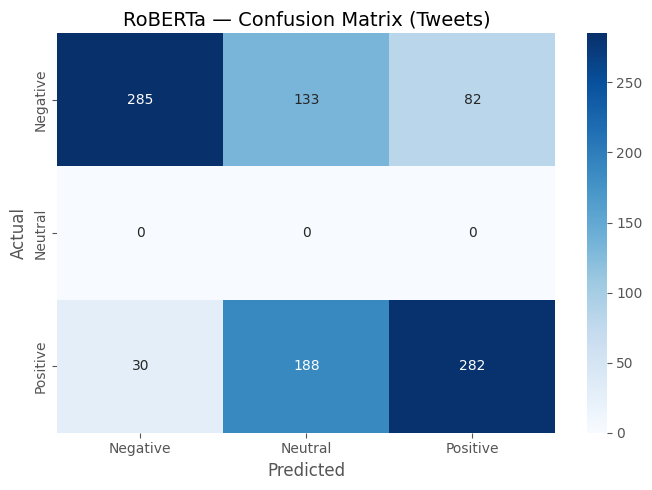

In [ ]:
# Confusion Matrix
labels_order = sorted(eval_df['predicted_sentiment'].unique())
cm = confusion_matrix(eval_df['true_sentiment'], eval_df['predicted_sentiment'],
                      labels=labels_order)

plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=labels_order, yticklabels=labels_order)
plt.title('RoBERTa — Confusion Matrix (Tweets)', fontsize=14)
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

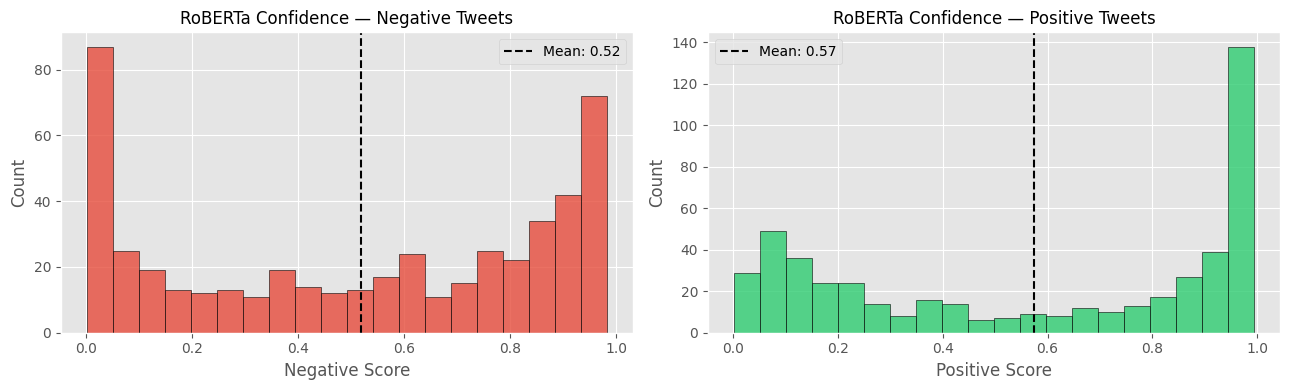

In [ ]:
# Confidence score distributions
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

for ax, sentiment, color in zip(axes, ['Negative', 'Positive'], ['#e74c3c', '#2ecc71']):
    subset = eval_df[eval_df['true_sentiment'] == sentiment]
    score_col = 'neg_score' if sentiment == 'Negative' else 'pos_score'
    ax.hist(subset[score_col], bins=20, color=color, edgecolor='black', alpha=0.8)
    ax.set_title(f'RoBERTa Confidence — {sentiment} Tweets', fontsize=12)
    ax.set_xlabel(f'{sentiment} Score')
    ax.set_ylabel('Count')
    ax.axvline(subset[score_col].mean(), color='black', linestyle='--',
               label=f'Mean: {subset[score_col].mean():.2f}')
    ax.legend()

plt.tight_layout()
plt.show()

## 💾 Step 8: Save Results

In [ ]:
output_cols = ['id', 'user', 'text', 'clean_text',
               'true_sentiment', 'predicted_sentiment',
               'neg_score', 'neu_score', 'pos_score']

df_sample[output_cols].to_csv('twitter_roberta_results.csv', index=False)
print('✅ Results saved to twitter_roberta_results.csv')

✅ Results saved to twitter_roberta_results.csv


## ✍️ Step 9: Predict on Custom Tweets

In [ ]:
def predict_tweet(text):
    clean  = preprocess_tweet(text)
    result = predict_roberta(clean)
    label  = result['predicted_sentiment']
    emoji  = {'Positive': '✅', 'Neutral': '😐', 'Negative': '❌'}.get(label, '?')
    print(f'Tweet    : "{text}"')
    print(f'Sentiment: {emoji} {label}')
    print(f'Scores   → Neg: {result["neg_score"]:.3f} | '
          f'Neu: {result["neu_score"]:.3f} | '
          f'Pos: {result["pos_score"]:.3f}')
    print()

# ── Try your own tweets below! ────────────────────────────────────
predict_tweet("Just got my new phone and I absolutely love it! 🔥")
predict_tweet("This traffic is making me so frustrated, worst day ever 😤")
predict_tweet("Going to the mall later, not sure what to get.")

Tweet    : "Just got my new phone and I absolutely love it! 🔥"
Sentiment: ✅ Positive
Scores   → Neg: 0.002 | Neu: 0.006 | Pos: 0.992

Tweet    : "This traffic is making me so frustrated, worst day ever 😤"
Sentiment: ❌ Negative
Scores   → Neg: 0.977 | Neu: 0.019 | Pos: 0.004

Tweet    : "Going to the mall later, not sure what to get."
Sentiment: 😐 Neutral
Scores   → Neg: 0.266 | Neu: 0.688 | Pos: 0.047

